# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.55MB/s]

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[-0.9515, -0.0908, -0.3853,  0.1003,  0.4707,  0.7954,  0.3146,  0.2832,
          0.0752,  0.0590]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [7]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [8]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/5], Train Loss: 0.4098, Train Acc: 0.8823, Val Loss: 0.3343, Val Acc: 0.9062
Epoch [2/5], Train Loss: 0.3129, Train Acc: 0.9101, Val Loss: 0.3066, Val Acc: 0.9138
Epoch [3/5], Train Loss: 0.2969, Train Acc: 0.9165, Val Loss: 0.2992, Val Acc: 0.9175
Epoch [4/5], Train Loss: 0.2879, Train Acc: 0.9194, Val Loss: 0.2881, Val Acc: 0.9201
Epoch [5/5], Train Loss: 0.2812, Train Acc: 0.9211, Val Loss: 0.2927, Val Acc: 0.9195


In [9]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2812
Última acurácia de treinamento: 0.9211
Última perda de validação: 0.2927
Última acurácia de validação: 0.9195


### Visualizando a evolução da perda e acurácia

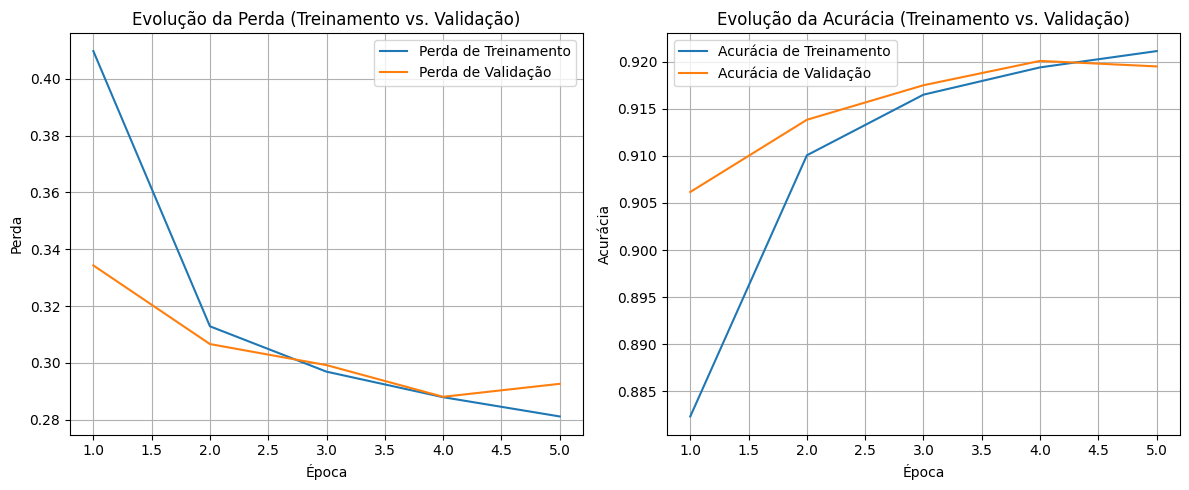

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch? R:  cada mini-batch contém 100 amostras.
2. Em uma época, quantos mini-batches existem? R: 48.000 amostras de treinamento ÷ 100 por batch = 480 mini-batches por época
3. Qual é a definição de época? R: Uma época é uma passagem completa por todo o conjunto de treinamento

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600

In [11]:
# Print no final de cada mini-batch
print('Época: {}/{}, batch: {}'.format(epoch+1, n_epochs, i+1))

Época: 5/5, batch: 480


In [12]:
for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Print no final de cada mini-batch
        print('Época: {}/{}, batch: {}'.format(epoch+1, n_epochs, i+1))

Época: 5/5, batch: 1
Época: 5/5, batch: 2
Época: 5/5, batch: 3
Época: 5/5, batch: 4
Época: 5/5, batch: 5
Época: 5/5, batch: 6
Época: 5/5, batch: 7
Época: 5/5, batch: 8
Época: 5/5, batch: 9
Época: 5/5, batch: 10
Época: 5/5, batch: 11
Época: 5/5, batch: 12
Época: 5/5, batch: 13
Época: 5/5, batch: 14
Época: 5/5, batch: 15
Época: 5/5, batch: 16
Época: 5/5, batch: 17
Época: 5/5, batch: 18
Época: 5/5, batch: 19
Época: 5/5, batch: 20
Época: 5/5, batch: 21
Época: 5/5, batch: 22
Época: 5/5, batch: 23
Época: 5/5, batch: 24
Época: 5/5, batch: 25
Época: 5/5, batch: 26
Época: 5/5, batch: 27
Época: 5/5, batch: 28
Época: 5/5, batch: 29
Época: 5/5, batch: 30
Época: 5/5, batch: 31
Época: 5/5, batch: 32
Época: 5/5, batch: 33
Época: 5/5, batch: 34
Época: 5/5, batch: 35
Época: 5/5, batch: 36
Época: 5/5, batch: 37
Época: 5/5, batch: 38
Época: 5/5, batch: 39
Época: 5/5, batch: 40
Época: 5/5, batch: 41
Época: 5/5, batch: 42
Época: 5/5, batch: 43
Época: 5/5, batch: 44
Época: 5/5, batch: 45
Época: 5/5, batch: 

2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

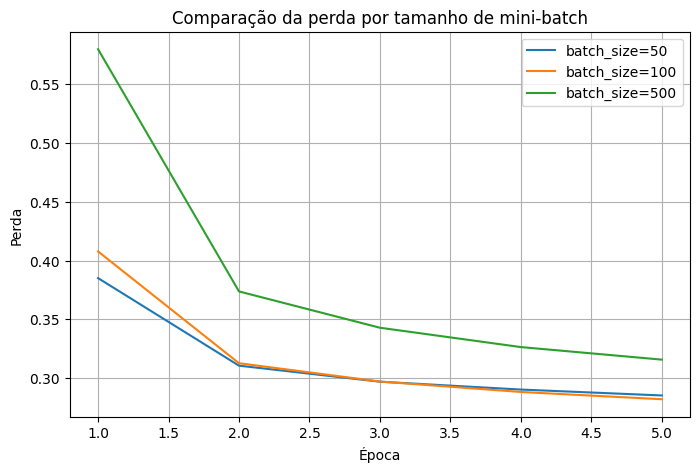

In [13]:
batch_sizes = [50, 100, 500]
results = {}

for bs in batch_sizes:
    # Recria o modelo e o loader para cada batch_size
    model_bs = torch.nn.Linear(28*28, 10)
    optimizer_bs = torch.optim.SGD(model_bs.parameters(), lr=0.5)
    loader_bs = DataLoader(dataset_train, batch_size=bs, shuffle=True)

    losses_bs = []
    for epoch in range(n_epochs):
        model_bs.train()
        running_loss = 0.0
        for x_b, y_b in loader_bs:
            inputs = x_b.view(-1, 28*28)
            outputs = model_bs(inputs)
            loss = criterion(outputs, y_b)
            optimizer_bs.zero_grad()
            loss.backward()
            optimizer_bs.step()
            running_loss += loss.item()
        losses_bs.append(running_loss / len(loader_bs))

    results[bs] = losses_bs

# Plot comparativo
plt.figure(figsize=(8, 5))
for bs, losses in results.items():
    plt.plot(range(1, n_epochs+1), losses, label=f'batch_size={bs}')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Comparação da perda por tamanho de mini-batch')
plt.legend()
plt.grid(True)
plt.show()

## Conclusões sobre os experimentos deste notebook


- Mini-batches menores (ex: 50) geram atualizações mais ruidosas, mas o modelo converge mais rapidamente em termos de épocas — porém o treinamento é mais lento por época pois há mais atualizações.
- Mini-batches maiores (ex: 500) geram gradientes mais estáveis e suaves, mas podem convergir mais lentamente e consumir mais memória.
- O DataLoader com shuffle=True é essencial no treinamento por mini-batches para evitar que a rede aprenda a ordem dos dados, garantindo que cada mini-batch seja uma amostra aleatória representativa do dataset.
- model.train() e model.eval() devem ser chamados nas fases de treinamento e validação respectivamente, pois algumas camadas (como Dropout e BatchNorm) se comportam de forma diferente em cada modo.
- torch.no_grad() na validação desabilita o cálculo de gradientes, economizando memória e acelerando a inferência.
